## 🔬 Experiment 1: Reasoning Transfer via Precomputed Context

### 🎯 Core Hypothesis
> *Reasoning steps (tokens) computed for a single, complex sample can be extracted, "frozen," and injected as precomputed context into subsequent queries. This transfer will improve the LLM's performance (accuracy/consistency) on new samples of the same domain compared to standard zero-shot generation.*

### ⚙️ Pipeline Architecture
0. **Reasoning Token Extraction:** Prompt Qwen 3.5:4b with a random sample question from the data set "", strip the final answer, and store *only* the reasoning tokens as a static string.
1. **Baseline:** For each sample of the data-set, prompt Qwen 3.5:4b with the sample, turn-off thinking and force the model to only awnser the question.
2. **Injection:** For each sample of the data-set, prompt Qwen 3.5:4b with the sample, turn-off thinking, add the extracted reasoning tokens and force the model to only awnser the question.

### 📊 Evaluation Metrics
* **Accuracy:** Does the injected context increase the rate of correctly solved subsequent samples?
* **Efficiency:** Does the provision of precomputed reasoning reduce the total generation time or token count for subsequent queries?

In [1]:
import time
import json
import os
import subprocess
import random
from datetime import datetime
from langchain_ollama import ChatOllama
from langchain_core.messages import HumanMessage, SystemMessage
from datasets import load_dataset

In [2]:
# Dynamic IP retrieval for Windows host
windows_ip = subprocess.check_output("ip route list default | awk '{print $3}'", shell=True).decode('utf-8').strip()

# Set llm model parameters (qwen3.5:4b)
llm_model = ChatOllama(
    model="qwen3.5:4b", 
    base_url=f"http://{windows_ip}:11434", 
    presence_penalty=1.5,
    temperature=1,
    top_p=0.95,
    top_k=20,
)

In [3]:
# Load WinoGrande dataset and select a subset for the experiment
dataset = load_dataset("allenai/winogrande", "winogrande_s")
experiment0_samples = dataset['validation'].select(range(200))

In [4]:
# 1. Get a random anchor sample for extraction
anchor_index = random.randint(0, len(experiment0_samples)-1)
anchor_sample = experiment0_samples[anchor_index]
anchor_question = f"Question: {anchor_sample['sentence']}, Options: {anchor_sample['option1']} or {anchor_sample['option2']}."

print(f"Anchor Sample selected (Index {anchor_index}): {anchor_question}")

# 2. Define prompt structures as variables
system_instruction = "You are a meticulous assistant. Fill in the blank (_) in the sentence with the logically correct option."
baseline_prompt_structure = "Question: {sentence}, Options: {option1} or {option2}. Please provide only the correct option as the answer."
injected_prompt_structure = "{preprocessed_reasoning_tokens}\n\nQuestion: {sentence}, Options: {option1} or {option2}. Please provide only the correct option as the answer."

# 3. Preprocessing: Generate LLM reasoning for the anchor
preprocessed_reasoning_tokens = llm_model.invoke([
    SystemMessage(content=system_instruction),
    # We manually append the instruction for the anchor run
    HumanMessage(content=f"{anchor_question} Please provide only the correct option as the answer.")
], reasoning=True).additional_kwargs.get("reasoning_content")

print("\nPreprocessed Reasoning Tokens:", preprocessed_reasoning_tokens, "\n")

# 4. Initialize new log structure
experiment_log = {
    "metadata": {
        "dataset": "WinoGrande",
        "anchor_sample_index": anchor_index,
        "anchor_question": anchor_question,
        "injected_reasoning_tokens": preprocessed_reasoning_tokens,
        "system_prompt": system_instruction,
        "baseline_prompt_structure": baseline_prompt_structure,
        "injected_prompt_structure": injected_prompt_structure
    },
    "results": {}
}

# 5. The main loop
for index, sample in enumerate(experiment0_samples):
    sample_id = f"sample_{index:03d}"
    correct_solution = sample[f"option{sample['answer']}"]
    
    # Cleanly fill prompts via .format() using the template variables
    baseline_human_prompt = baseline_prompt_structure.format(
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )
    
    injected_human_prompt = injected_prompt_structure.format(
        preprocessed_reasoning_tokens=preprocessed_reasoning_tokens,
        sentence=sample['sentence'],
        option1=sample['option1'],
        option2=sample['option2']
    )

    # Baseline Run
    response_baseline = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=baseline_human_prompt)
    ], reasoning=False)
    baseline_answer = response_baseline.content.strip()

    # Injected Run
    response_injected = llm_model.invoke([
        SystemMessage(content=system_instruction),
        HumanMessage(content=injected_human_prompt)
    ], reasoning=False)
    injected_answer = response_injected.content.strip()

    print(f"{sample_id} - Solution: {correct_solution} | Baseline: {baseline_answer} vs. Injected: {injected_answer}")
    
    # Write results to the results dictionary
    experiment_log["results"][sample_id] = {
        "solution": correct_solution,
        "llm_baseline": baseline_answer,
        "llm_preprocessedReasoning": injected_answer 
    }

# 6. Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
log_filename = f"qwen_experiment_log_{timestamp}.json"

with open(log_filename, "w", encoding="utf-8") as f:
    json.dump(experiment_log, f, indent=4, ensure_ascii=False)

print(f"\n✅ Experiment successfully saved in {log_filename}!")

Anchor Sample selected (Index 185): Question: Pete preferred to use the sheet to the blanket, because the _ was much hotter., Options: sheet or blanket.

Preprocessed Reasoning Tokens: Thinking Process:

1.  **Analyze the Request:**
    *   Input: A sentence with a blank ("Pete preferred to use the sheet to the blanket, because the _ was much hotter.").
    *   Task: Fill in the blank with the logically correct option ("sheet" or "blanket").
    *   Constraint: Provide *only* the correct option as the answer.

2.  **Analyze the Sentence:**
    *   "Pete preferred to use the sheet to the blanket" -> Wait, there might be a preposition error in the original sentence ("to" instead of "over" or "instead of"?). Usually, it would be "Pete preferred to use the sheet *over* the blanket" or "Pete preferred to use the sheet *instead of* the blanket". However, I need to focus on the logical reasoning provided in the second part of the sentence.
    *   "because the _ was much hotter."
    *   Reas

## Results

📊 WinoGrande Experiment Results:
Total Samples analyzed: 200
----------------------------------------
🔴 Baseline Accuracy: 66.0% (132/200)
🟢 Injected Accuracy: 55.0% (110/200)

⚠️ Interesting: The baseline was stronger. The injected, foreign thought process confused the model here.

📸 Plot successfully saved as: qwen_experiment_plot_20260501_001152.png


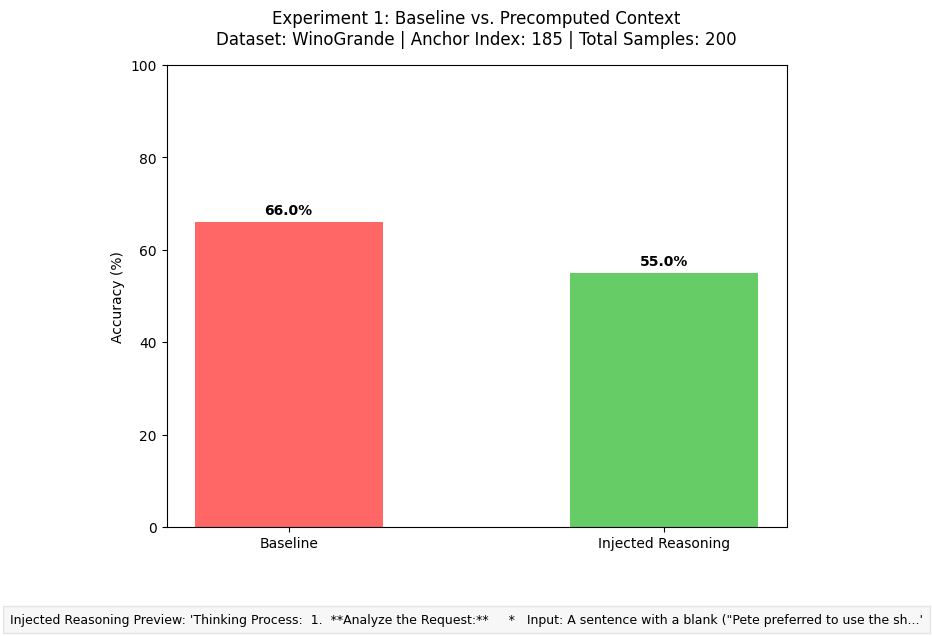

In [5]:
import json
import matplotlib.pyplot as plt

# 1. Safely split the log into metadata and results
metadata = experiment_log.get("metadata", {})
results = experiment_log.get("results", {})

total_samples = len(results)
baseline_correct = 0
injected_correct = 0

for sample_id, data in results.items():
    # Convert to lowercase and strip whitespace for fair comparison
    solution = str(data["solution"]).strip().lower()
    baseline = str(data["llm_baseline"]).strip().lower()
    injected = str(data["llm_preprocessedReasoning"]).strip().lower()
    
    # Check: Is the correct word contained in the model's answer?
    if solution in baseline:
        baseline_correct += 1
    if solution in injected:
        injected_correct += 1

# Calculate percentage accuracy
baseline_accuracy = (baseline_correct / total_samples) * 100 if total_samples > 0 else 0
injected_accuracy = (injected_correct / total_samples) * 100 if total_samples > 0 else 0

# 📊 The Big Reveal (Console Output)
print("📊 WinoGrande Experiment Results:")
print("=" * 40)
print(f"Total Samples analyzed: {total_samples}")
print("-" * 40)
print(f"🔴 Baseline Accuracy: {baseline_accuracy:.1f}% ({baseline_correct}/{total_samples})")
print(f"🟢 Injected Accuracy: {injected_accuracy:.1f}% ({injected_correct}/{total_samples})")
print("=" * 40)

# Hypothesis Conclusion Generator
if injected_accuracy > baseline_accuracy:
    print("\n🎉 Hypothesis validated: The Precomputed Context (Reasoning Transfer) measurably improved the model!")
elif injected_accuracy == baseline_accuracy:
    print("\n⚖️ Tie: In this sample set, the injection had no statistical effect.")
else:
    print("\n⚠️ Interesting: The baseline was stronger. The injected, foreign thought process confused the model here.")

# 📈 Generate and Save the Plot
labels = ['Baseline', 'Injected Reasoning']
accuracies = [baseline_accuracy, injected_accuracy]
colors = ['#ff6666', '#66cc66'] # Red and Green styling

plt.figure(figsize=(8, 6))
bars = plt.bar(labels, accuracies, color=colors, width=0.5)

# 💡 Extract Metadata for the Plot
dataset_name = metadata.get("dataset", "Unknown")
anchor_index = metadata.get("anchor_sample_index", "Unknown")

plt.ylabel('Accuracy (%)')

# Add a multi-line title containing the experiment parameters
plt.title(f'Experiment 1: Baseline vs. Precomputed Context\n'
          f'Dataset: {dataset_name} | Anchor Index: {anchor_index} | Total Samples: {total_samples}', 
          fontsize=12, pad=15)

plt.ylim(0, 100) # Keep Y-axis fixed from 0 to 100 for proper scientific scale

# Add text annotations directly on top of the bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, f'{yval:.1f}%', ha='center', va='bottom', fontweight='bold')

# 💡 Add a text box at the bottom with a preview of the injected reasoning
reasoning_preview = metadata.get("injected_reasoning_tokens", "")
# Truncate string if it's too long so it doesn't break the image layout
if len(reasoning_preview) > 120:
    reasoning_preview = reasoning_preview[:117] + "..."
    
# Replace newlines with spaces for a cleaner one-line preview
reasoning_preview = reasoning_preview.replace('\n', ' ')

plt.figtext(0.5, -0.05, f"Injected Reasoning Preview: '{reasoning_preview}'", 
            ha="center", fontsize=9, bbox={"facecolor":"#f0f0f0", "alpha":0.5, "pad":5, "edgecolor":"#cccccc"})

# Save the plot using the timestamp from the previous cell
# (Assuming 'timestamp' is still stored in your notebook's memory)
plot_filename = f"qwen_experiment_plot_{timestamp}.png"
plt.savefig(plot_filename, bbox_inches='tight', dpi=300) 
print(f"\n📸 Plot successfully saved as: {plot_filename}")

# Display the plot directly in the Jupyter Notebook cell
plt.show()